# Week 6 - MobileNetV2 Transfer Learning, Phase 2 (Fine-Tuning)

**Project:** Image-Based Fruit Ripeness Classification (STU141830)

**Strategy.** Load the Phase 1 model (frozen base + trained head), unfreeze the top blocks of the MobileNetV2 base, and continue training with a very low learning rate so the high-level features adapt to the fruit domain without destroying the pre-trained ImageNet representations.

**Key design choices (following the official TensorFlow/Keras fine-tuning guidance):**

1. **Selective unfreezing.** Only layers from index `FINE_TUNE_AT = 100` onward become trainable (the last inverted-residual blocks). Layers below stay frozen, preserving generic low-level features.
2. **BatchNormalization stays frozen.** Every BN layer is kept non-trainable (inference mode) so it uses the ImageNet population statistics. Updating BN statistics on a 315-image training set would corrupt the pre-trained calibration. This is the critical fine-tuning gotcha.
3. **Learning rate = 1e-5.** One hundred times smaller than Phase 1 (1e-3). A larger rate would overwrite the pre-trained weights.
4. **Continue from the Phase 1 checkpoint** rather than retraining from scratch.

**Prerequisite.** Run notebook `04` first - it builds `dataset_splits/` from `data_split.csv` and produces `saved_models/mobilenet_phase1_best.h5`.


In [23]:
# Imports and reproducibility
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import optimizers, callbacks
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', bool(gpus), gpus)


TensorFlow: 2.11.0
GPU available: False []


In [24]:
# Paths and config
PROJECT_ROOT = Path.cwd().parent  # notebook lives in notebooks/
DATASET_DIR = PROJECT_ROOT / 'dataset_splits'   # built by notebook 04
SAVED_MODELS_DIR = PROJECT_ROOT / 'saved_models'
RESULTS_DIR = PROJECT_ROOT / 'results'
SAVED_MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
PHASE2_EPOCHS = 20
FINE_TUNE_AT = 100      # unfreeze base layers from this index onward
LR = 1e-5               # 100x smaller than Phase 1
NUM_CLASSES = 9
MODEL_NAME = 'mobilenet_phase2'
PHASE1_MODEL = 'mobilenet_phase1'

phase1_ckpt = SAVED_MODELS_DIR / f'{PHASE1_MODEL}_best.h5'
phase2_ckpt = SAVED_MODELS_DIR / f'{MODEL_NAME}_best.h5'

# Prerequisite checks
assert DATASET_DIR.exists(), (
    f'{DATASET_DIR} not found. Run notebook 04 first - it builds dataset_splits/ from data_split.csv.'
)
assert phase1_ckpt.exists(), (
    f'{phase1_ckpt} not found. Run notebook 04 to train and save the Phase 1 model first.'
)

for split in ('train', 'val', 'test'):
    split_dir = DATASET_DIR / split
    assert split_dir.exists(), f'Missing directory: {split_dir}'
    classes = sorted([p.name for p in split_dir.iterdir() if p.is_dir()])
    print(f'{split:5s}: {len(classes)} classes')

print('\nPhase 1 checkpoint:', phase1_ckpt)
print('Phase 2 save path: ', phase2_ckpt)


train: 9 classes
val  : 9 classes
test : 9 classes

Phase 1 checkpoint: d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase1_best.h5
Phase 2 save path:  d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase2_best.h5


In [25]:
# Raw data loaders (identical setup to Phase 1)
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR / 'train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=SEED
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR / 'val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds_raw.class_names
print('\nClasses:', class_names)
assert len(class_names) == NUM_CLASSES, f'Expected {NUM_CLASSES} classes, got {len(class_names)}'


Found 315 files belonging to 9 classes.
Found 63 files belonging to 9 classes.

Classes: ['apple_overripe', 'apple_ripe', 'apple_unripe', 'banana_overripe', 'banana_ripe', 'banana_unripe', 'pear_overripe', 'pear_ripe', 'pear_unripe']


In [26]:
# Augmentation (training only) + MobileNetV2 preprocessing -- identical to Phase 1
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal', seed=SEED),
    layers.RandomRotation(0.1, seed=SEED),
    layers.RandomZoom(0.1, seed=SEED),
], name='data_augmentation')

AUTOTUNE = tf.data.AUTOTUNE

def prep_train(x, y):
    x = data_augmentation(x, training=True)
    x = preprocess_input(x)
    return x, y

def prep_val(x, y):
    x = preprocess_input(x)
    return x, y

train_ds = train_ds_raw.map(prep_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds_raw.map(prep_val, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


In [27]:
# Load the Phase 1 model (compile=False -> fresh recompile below)
model = tf.keras.models.load_model(str(phase1_ckpt), compile=False)

# The MobileNetV2 base is the first layer of the Sequential model
base_model = model.layers[0]
print('Base model:', base_model.name)
print('Base sub-layers:', len(base_model.layers))
assert len(base_model.layers) > 100, 'Expected MobileNetV2 base with >100 layers'

# Confirm Phase 1 weights loaded by checking head output shape
print('Model output shape:', model.output_shape)


Base model: mobilenetv2_1.00_224
Base sub-layers: 154
Model output shape: (None, 9)


In [28]:
# Unfreeze top blocks; keep lower layers and ALL BatchNorm frozen
base_model.trainable = True

# Freeze everything before the fine-tune cutoff
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Keep every BatchNormalization layer frozen (inference mode) regardless of position
bn_frozen = 0
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
        bn_frozen += 1

# Recompile with a low learning rate (mandatory after changing trainable flags)
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = int(sum(tf.keras.backend.count_params(w) for w in model.trainable_weights))
non_trainable = int(sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights))
unfrozen_in_base = sum(1 for l in base_model.layers if l.trainable)

print(f'Fine-tune cutoff (FINE_TUNE_AT): {FINE_TUNE_AT}')
print(f'BatchNorm layers kept frozen:    {bn_frozen}')
print(f'Unfrozen layers in base:         {unfrozen_in_base}')
print(f'Trainable params:     {trainable:,}')
print(f'Non-trainable params: {non_trainable:,}')
print(f'Total params:         {trainable + non_trainable:,}')


Fine-tune cutoff (FINE_TUNE_AT): 100
BatchNorm layers kept frozen:    52
Unfrozen layers in base:         36
Trainable params:     1,851,145
Non-trainable params: 418,368
Total params:         2,269,513


In [29]:
# Callbacks
cb_list = [
    callbacks.ModelCheckpoint(
        filepath=str(phase2_ckpt),
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]


In [30]:
# Fine-tune
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=cb_list,
    verbose=1
)


Epoch 1/20
10/10 [==============================] - ETA: 0s - loss: 0.1475 - accuracy: 0.9556
Epoch 1: val_loss improved from inf to 0.42064, saving model to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase2_best.h5
10/10 [==============================] - 10s 573ms/step - loss: 0.1475 - accuracy: 0.9556 - val_loss: 0.4206 - val_accuracy: 0.8413 - lr: 1.0000e-05
Epoch 2/20
10/10 [==============================] - ETA: 0s - loss: 0.1055 - accuracy: 0.9714
Epoch 2: val_loss improved from 0.42064 to 0.39178, saving model to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase2_best.h5
10/10 [==============================] - 7s 491ms/step - loss: 0.1055 - accuracy: 0.9714 - val_loss: 0.3918 - val_accuracy: 0.8730 - lr: 1.0000e-05
Epoch 3/20
10/10 [==============================] - ETA: 0s - loss: 0.0890 - accuracy: 0.9810
Epoch 3: val_loss improved from 0.39178 to 0.37965, saving model to d:\Arden Uni\

In [31]:
# Persist Phase 2 history and append rows to results.csv
hist_dict = {k: [float(v) for v in vals] for k, vals in history_ft.history.items()}
with open(RESULTS_DIR / f'{MODEL_NAME}_history.json', 'w') as f:
    json.dump(hist_dict, f, indent=2)

hist_df = pd.DataFrame(history_ft.history)
hist_df.insert(0, 'epoch', range(1, len(hist_df) + 1))
hist_df.insert(0, 'phase', 'finetune')
hist_df.insert(0, 'model', MODEL_NAME)

results_csv = RESULTS_DIR / 'results.csv'
if results_csv.exists():
    existing = pd.read_csv(results_csv)
    if 'model' in existing.columns and 'phase' in existing.columns:
        mask = ~((existing['model'] == MODEL_NAME) & (existing['phase'] == 'finetune'))
        existing = existing[mask]
    out_df = pd.concat([existing, hist_df], ignore_index=True, sort=False)
else:
    out_df = hist_df
out_df.to_csv(results_csv, index=False)
print(f'Logged {len(hist_df)} rows to {results_csv}')
print(f'Saved history JSON: {RESULTS_DIR / f"{MODEL_NAME}_history.json"}')


Logged 20 rows to d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results\results.csv
Saved history JSON: d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results\mobilenet_phase2_history.json


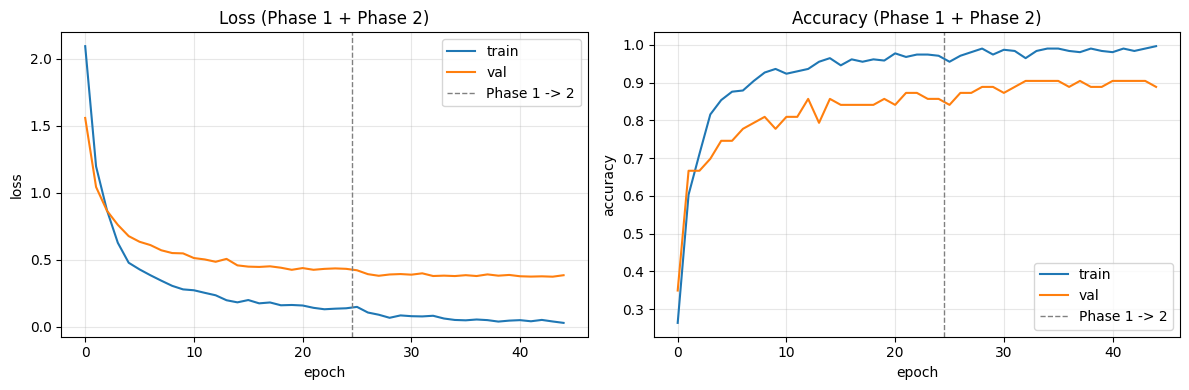

Saved plot: d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\results\mobilenet_phase2_training_curves.png


In [32]:
# Combined training curves: Phase 1 (frozen) -> Phase 2 (fine-tune)
phase1_hist_path = RESULTS_DIR / f'{PHASE1_MODEL}_history.json'

if phase1_hist_path.exists():
    with open(phase1_hist_path) as f:
        p1 = json.load(f)
    split_epoch = len(p1['loss'])
    loss_all = p1['loss'] + history_ft.history['loss']
    val_loss_all = p1['val_loss'] + history_ft.history['val_loss']
    acc_all = p1['accuracy'] + history_ft.history['accuracy']
    val_acc_all = p1['val_accuracy'] + history_ft.history['val_accuracy']
    title_suffix = ' (Phase 1 + Phase 2)'
else:
    split_epoch = None
    loss_all = history_ft.history['loss']
    val_loss_all = history_ft.history['val_loss']
    acc_all = history_ft.history['accuracy']
    val_acc_all = history_ft.history['val_accuracy']
    title_suffix = ' (Phase 2 only)'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_all, label='train', linewidth=1.5)
axes[0].plot(val_loss_all, label='val', linewidth=1.5)
if split_epoch is not None:
    axes[0].axvline(split_epoch - 0.5, color='gray', linestyle='--', linewidth=1, label='Phase 1 -> 2')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].set_title('Loss' + title_suffix)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(acc_all, label='train', linewidth=1.5)
axes[1].plot(val_acc_all, label='val', linewidth=1.5)
if split_epoch is not None:
    axes[1].axvline(split_epoch - 0.5, color='gray', linestyle='--', linewidth=1, label='Phase 1 -> 2')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_title('Accuracy' + title_suffix)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = RESULTS_DIR / f'{MODEL_NAME}_training_curves.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved plot: {plot_path}')


In [33]:
# Final summary + comparison against Phase 1
val_losses = history_ft.history['val_loss']
val_accs = history_ft.history['val_accuracy']
best_idx = int(np.argmin(val_losses))

print('=' * 60)
print('PHASE 2 FINE-TUNING SUMMARY')
print('=' * 60)
print(f'Model:               {MODEL_NAME}')
print(f'Total epochs run:    {len(val_losses)}')
print(f'Best epoch:          {best_idx + 1} (min val_loss)')
print(f'Best val_loss:       {val_losses[best_idx]:.4f}')
print(f'Best val_accuracy:   {val_accs[best_idx]:.4f} ({val_accs[best_idx]*100:.2f}%)')
print(f'Train_loss at best:  {history_ft.history["loss"][best_idx]:.4f}')
print(f'Train_acc at best:   {history_ft.history["accuracy"][best_idx]:.4f}')
print(f'Saved model:         {phase2_ckpt}')

if phase1_hist_path.exists():
    p1_best_idx = int(np.argmin(p1['val_loss']))
    p1_best_acc = p1['val_accuracy'][p1_best_idx]
    delta = (val_accs[best_idx] - p1_best_acc) * 100
    print('-' * 60)
    print(f'Phase 1 best val_accuracy: {p1_best_acc*100:.2f}%')
    print(f'Phase 2 best val_accuracy: {val_accs[best_idx]*100:.2f}%')
    print(f'Delta (Phase 2 - Phase 1): {delta:+.2f} pp')
print('=' * 60)
print('Next step (Week 7): full test-set evaluation + Grad-CAM on the Phase 2 model.')


PHASE 2 FINE-TUNING SUMMARY
Model:               mobilenet_phase2
Total epochs run:    20
Best epoch:          19 (min val_loss)
Best val_loss:       0.3728
Best val_accuracy:   0.9048 (90.48%)
Train_loss at best:  0.0386
Train_acc at best:   0.9905
Saved model:         d:\Arden Uni\IV Year (Level 6)\Final Project\week1\fruit_ripeness\saved_models\mobilenet_phase2_best.h5
------------------------------------------------------------
Phase 1 best val_accuracy: 85.71%
Phase 2 best val_accuracy: 90.48%
Delta (Phase 2 - Phase 1): +4.76 pp
Next step (Week 7): full test-set evaluation + Grad-CAM on the Phase 2 model.
